# S&P 500 Equity + Option Analytics: Feature Engineering

Most feature matrices in this book are built from one market's history. This one is built from
two. Every session, the options listed on a name are quoted at a range of strikes and expiry
dates, and the **implied volatility** of any one of them is the volatility that would justify
the price it trades at. Summarized across strike and expiry, that is the name's **implied
volatility surface**: what the option market charges today for the size of the move it expects
over the coming weeks. The share price says what the equity market pays for the same name. The
claim under test is that the disagreement between the two ranks names against each other.

The two sources do not become knowable at the same moment, so *when* each may be read is as
much of the work here as what is computed from it. This notebook builds the feature families,
writes that timing difference down once as a per-family delay, shows that withholding later
dates leaves every value unchanged, and writes the matrix stage 04 and stage 05 read.

## Learning objectives

- Turn an implied volatility level, which is not comparable between a utility quoted at twenty
  percent and a semiconductor quoted at fifty, into a z-score and a percentile against each
  name's own recent history, which are comparable across names
- Delay every option-derived column by the one session it takes for a day's option quotes to
  become readable, leave the share-price columns undelayed, and take that delay from one
  declared number rather than from a list of columns someone has to keep up to date
- Count a delay and a window in trading sessions when the input they run over is quoted only
  on some of those sessions, by putting the sparse input on the security's own session calendar
  before anything reads it
- Rebuild the matrix with the later dates withheld and compare every value on the rows the two
  builds share, which is how a transform fitted across the whole sample is caught without
  anyone having flagged it
- Read a feature matrix before modelling it: the scale each column arrives on, how far the
  names disagree on a date, how much of the set is one ordering under several names, and how
  long a value lasts

## Book reference, prerequisites and artifacts

Chapter 8, Sections 8.1-8.6. Reads the daily share bars and the daily option-surface summary
through `load_sp500_daily_bars()` and `load_sp500_options_surface()`, whose coverage
[`01_feasibility_analysis`](01_feasibility_analysis.ipynb) establishes, and `config/setup.yaml`,
which declares the register, every window, the ranked columns and the holdout boundary. Writes
`features/financial.parquet` with a `.digest.json` sidecar, read by
[`04_model_based_features`](04_model_based_features.ipynb), which adds a fitted conditional
volatility beside these columns, and by [`05_evaluation`](05_evaluation.ipynb), which tests fold
by fold whether any of it predicts. No screen for predictive content runs here: `05_evaluation`
owns it and runs it fold-aware.

In [1]:
"""S&P 500 Equity + Option Analytics: Feature Engineering."""

import warnings
from datetime import date

import numpy as np
import polars as pl
import yaml

from case_studies.utils.artifact_digest import value_digest, write_artifact
from case_studies.utils.feature_engineering import (
    assert_values_agree,
    assign_families,
    families_from_config,
    family_coverage,
    plot_coverage_through_time,
    plot_cross_sectional_dispersion,
    plot_feature_distributions,
    plot_persistence,
    plot_redundancy_clusters,
    plot_timing_contract,
    register_frame,
    warmup_audit,
)
from data import load_sp500_daily_bars, load_sp500_options_surface
from utils.paths import display_path, get_case_study_dir

warnings.filterwarnings("ignore")

CASE_STUDY_ID = "sp500_equity_option_analytics"
CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
FEATURES_DIR = CASE_DIR / "features"

Both parameters bound the sample and both are read below. The share bars and the surface
summary are licensed extracts covering these five years, so the defaults span the data.
Trimming either end shortens a run at the cost of a shorter history for the trailing windows
in Section C, and every cross-sectional rank is taken within a date across whatever names are
quoted on it, so a trimmed run computes a different quantity rather than a smaller one.

In [2]:
START_DATE = "2017-01-01"
END_DATE = "2021-12-31"

## Configuration

The register, every window, the ranked-column mapping, the contract selection and the holdout
boundary are declared in `config/setup.yaml` and bound here. A window retyped into a cell is a
second source of truth for a decision the register, the warmup assertion and the timing figure
all have to agree on, and the two copies drift apart the first time either is edited.

Each setting below is printed as the decision it makes rather than as the number it holds. The
windows themselves appear beside the family that uses them.

In [3]:
setup = yaml.safe_load((CASE_DIR / "config" / "setup.yaml").read_text())
FEATURES = setup["features"]
FAMILIES = families_from_config(setup)
W = FEATURES["windows"]
RANKED = FEATURES["ranked"]
SURFACE = FEATURES["surface"]
HOLDOUT_START = date.fromisoformat(setup["evaluation"]["holdout_start"])
IV_LAG = int(setup["decision"]["iv_feature_lag"].split("_")[0])
DECISION_CYCLE = int(setup["labels"]["horizons"][setup["labels"]["primary"]].rstrip("Dd"))

# The panel key, the entity every trailing window is bounded by, and the partition every
# cross-sectional statistic is taken over.
PANEL_KEY = ["symbol", "timestamp"]
SECURITY = "sec_id"
WITHIN_DATE = "timestamp"

print(
    f"{len(FAMILIES)} feature families are declared, each with the history it reads and the "
    "delay it waits."
)
print(
    f"An option-derived column is read {IV_LAG} session after the close it summarizes; a "
    "share-price column is read at that close."
)
print(
    f"A missing option quote is carried forward across at most {W['iv_forward_fill']} trading "
    "sessions before the column is left empty."
)
print(
    f"Risk-adjusted momentum divides by an annualized volatility floored at "
    f"{W['risk_adjusted_vol_floor']:.0%}, so a share that barely moved over the quarter cannot "
    "take an unbounded ratio into the within-date ranking."
)
print(
    f"{len(RANKED)} columns are carried a second time as their standing among the names quoted "
    "that session."
)
print(
    f"The book rebalances every {DECISION_CYCLE} sessions, so a feature has to hold its ordering "
    f"for {DECISION_CYCLE} sessions to be tradable; that is what F6 looks for."
)
print(
    f"Everything from {HOLDOUT_START} onward is the holdout: no choice here reads it, and D.3 "
    "rebuilds the matrix without it to prove that."
)
print(
    f"Option contracts are selected by days to expiry {SURFACE['dte_buckets']} and by delta "
    f"{SURFACE['delta_targets']}, upstream of this notebook."
)

8 feature families are declared, each with the history it reads and the delay it waits.
An option-derived column is read 1 session after the close it summarizes; a share-price column is read at that close.
A missing option quote is carried forward across at most 5 trading sessions before the column is left empty.
Risk-adjusted momentum divides by an annualized volatility floored at 1%, so a share that barely moved over the quarter cannot take an unbounded ratio into the within-date ranking.
8 columns are carried a second time as their standing among the names quoted that session.
The book rebalances every 5 sessions, so a feature has to hold its ordering for 5 sessions to be tradable; that is what F6 looks for.
Everything from 2021-01-01 onward is the holdout: no choice here reads it, and D.3 rebuilds the matrix without it to prove that.
Option contracts are selected by days to expiry {'7d': [5, 10], '30d': [25, 35], '90d': [80, 110]} and by delta {'atm': 0.5, '25d': 0.25, '10d': 0.1},

## A. What the thesis says should carry information

The hypothesis is cross-sectional and it is about a disagreement between two markets. The
option market prices a distribution of outcomes for a name over the coming month; the share
price says what the equity market pays for it today. The claim is that names whose options are
priced richly against what their shares go on to do can be ranked against each other, and that
the ranking pays over the following week.

The family the hypothesis rests on is the **variance risk premium**: the level of implied
volatility against the volatility the share has actually realized, in volatility points. It is
the one number here that reads both markets, and `config/setup.yaml` names it as the treatment
the causal stage estimates an effect for. The families around it say where that premium is
coming from - the level of implied volatility itself, how the level moves, and the shape of the
surface across strike and across horizon.

The **conditioning** is realized volatility, which is a state variable rather than a signal:
it describes the dispersion a ranking has to be earned against and is not expected to rank
names on its own. Equity momentum is in the matrix for a different reason. It is the signal an
option-derived feature would have to replace, so carrying it is what makes a later comparison
mean anything.

The **frame** is the single decision date for every cross-sectional statistic and the security
for every trailing one. A level of implied volatility is not comparable between a utility and a
semiconductor, so eight of the columns are carried again as their percentile within the date.

The register is declared in `config/setup.yaml`, one row per family, and it is split by
**observability**: everything read off the option surface carries a one-session lag and
everything read off the share price does not, for the reason Section B gives.

In [4]:
register_frame(FAMILIES).select(
    ["family", "role", "inputs", "lookback (bars)", "lag (bars)", "frame"]
)

family,role,inputs,lookback (bars),lag (bars),frame
str,str,str,i64,i64,str
"""cross-sectional rank""","""signal""","""the eight level and dynamics c…",252,1,"""cross section within the decis…"
"""implied volatility level""","""signal""","""daily IV surface summary, delt…",1,1,"""time series"""
"""implied volatility dynamics""","""signal""","""at-the-money 30-day implied vo…",252,1,"""time series"""
"""skew and term structure""","""signal""","""25-delta put and call IV, and …",63,1,"""term structure"""
"""variance risk premium""","""signal""","""at-the-money implied volatilit…",63,1,"""time series"""
"""realized volatility""","""state""","""split- and dividend-adjusted O…",63,0,"""time series"""
"""equity momentum""","""signal""","""split- and dividend-adjusted c…",252,0,"""time series"""
"""surface quality""","""state""","""bid-ask spread and solver conv…",1,1,"""time series"""


## B. Inputs and their observability

Each row is one security and one session. Two frames arrive and they are not observable on the
same schedule.

The **share bars** arrive as printed prices beside `adj_factor`, the cumulative factor that puts
a price on a comparable footing with the rest of that security's history. A return taken on the
printed close is not a return: a four-for-one split reads as a three-quarter loss. Multiplying
gives the series every window below is taken over. A close is final at the close, so a statistic
of the closes through session $t$ is knowable at $t$ and carries no lag.

The entity every trailing window is bounded by is the **security**, `sec_id`, not the ticker. A
ticker is reassigned after a merger or a spin-off and `adj_factor` restarts with the new security,
so a window that steps across the change reads a price from one company against a price from
another. `02_labels` counts the changeovers in this extract and builds its labels the same way,
which is what makes a feature and the label it is scored against the same kind of quantity.

The **surface summary** reduces the option chain to one row per name and session, selecting the
contract closest to each delta target inside each fixed maturity bucket. Selecting by delta
rather than by strike is what makes the same column mean the same thing for a name whose strike
ladder is coarse and one whose ladder is fine. Those buckets and targets are declared in
`config/setup.yaml` and printed above; the selection itself runs in
`data/equities/market/sp500/materialize_options.py`, upstream of this notebook.

**A name has a surface row only on sessions its options quoted, and even then the value can be
missing.** An implied volatility is *solved for* rather than quoted: the option's price is
observed and the volatility that reproduces it is found numerically. That solve fails when the
quote is too wide or the contract too far from the money to pin a volatility down, and the
loader returns a failed solve as a null rather than as the vendor's placeholder. It also nulls
every measure computed from a failed point, so a slope between the 30-day and the 90-day
maturities is missing whenever either of them is. The table below is what that leaves, and the
coverage column is the one to read first.

**The surface is not knowable at the session it is dated.** End-of-day implied volatility is
solved and published after the close, so every surface column is shifted by the session
`setup.yaml::decision.iv_feature_lag` declares before anything is computed from it. The
dynamics in C.1 are then built on the lagged series rather than lagged after the fact, so a
z-score never mixes a lagged level with an unlagged history.

**The lag is counted in sessions, which is why the surface is reindexed before anything reads
it.** A name is not quoted on every session, so a shift over the surface's own rows would reach
back to whenever that name was last quoted and hand the model a fortnight-old level under the
name of yesterday's. Joining the surface onto the sessions the security traded makes the missing
ones visible as nulls, and every window after it - the lag, the fill, the momentum, the z-scores
and the trailing percentile - then counts sessions and means what the register says it means. The
forward fill carries a level over at most the number of sessions `features.windows.iv_forward_fill`
declares, which is a stated tolerance for a thin quote rather than a claim that the level is
current.

**The universe is bounded before either frame is read, and the bound is the one
`setup.yaml::universe` declares.** `eligibility_rule` is `sp500_with_options`, and what makes a
name satisfy it is carrying an option surface, because the surface is what the ranking is read
off. The share-bar extract is wider than that and the loader takes a `symbols=` argument nothing
was passing. The keep-or-drop in Section C would have removed the surplus names from the matrix
anyway, so bounding here moves no emitted value; what it changes is that the universe becomes a
stated bound rather than a by-product of a later filter. The roster is derived from the surface
rather than typed out, and every roster name is checked against the share bars.

The roster is read off the **whole** extract rather than off the requested window, because which
names have listed options is a property of the dataset rather than of a run. How many that comes
to is reported rather than asserted: `n_assets` describes the production extract, and the reduced
one CI runs on carries a handful of names by design.
`tests/test_eoa_universe_roster.py` holds the declaration to the production data.

In [5]:
full_surface = load_sp500_options_surface()
full_bars = load_sp500_daily_bars()
ROSTER = sorted(full_surface["symbol"].unique().to_list())
assert ROSTER, "the option-surface extract carries no names to rank"
priced = set(full_bars["symbol"].unique().to_list())
assert not set(ROSTER) - priced, f"no share bars for {sorted(set(ROSTER) - priced)}"
outside = sorted(priced - set(ROSTER))

window = pl.col("timestamp").is_between(
    pl.lit(START_DATE).str.to_date(), pl.lit(END_DATE).str.to_date()
)
surface_raw = full_surface.filter(window)
SURFACE_COLS = [c for c in surface_raw.columns if c not in PANEL_KEY]

daily = (
    full_bars.filter(window & pl.col("symbol").is_in(ROSTER))
    .with_columns((pl.col("close") * pl.col("adj_factor")).alias("adj_close"))
    .sort([SECURITY, "timestamp"])
)

print(f"{daily.height:,} name-sessions of share bars, {daily['symbol'].n_unique()} tickers")
print(f"{daily[SECURITY].n_unique()} securities behind those tickers")
print(f"{surface_raw.height:,} surface rows carrying {len(SURFACE_COLS)} columns")
print(f"{daily['timestamp'].min()} to {daily['timestamp'].max()}")
DECLARED = setup["universe"]["n_assets"]
print(
    f"Universe {len(ROSTER)} names with an option surface"
    + ("" if len(ROSTER) == DECLARED else f" (a reduced extract; n_assets declares {DECLARED})")
    + f"; {len(outside)} priced names carry none and are excluded ({', '.join(outside)})"
)

632,602 name-sessions of share bars, 633 tickers
624 securities behind those tickers
530,503 surface rows carrying 13 columns
2017-01-03 to 2021-12-31
Universe 633 names with an option surface; 5 priced names carry none and are excluded (BF.B, BMS, BRK.B, NVR, ONL)


In [6]:
SURFACE_DESCRIPTIONS = {
    "iv_30_atm": "at-the-money implied volatility, 30-day maturity, call and put averaged",
    "iv_7_atm": "at-the-money implied volatility, 7-day maturity",
    "iv_90_atm": "at-the-money implied volatility, 90-day maturity",
    "iv_30_put_25d": "25-delta put implied volatility, 30-day maturity",
    "iv_30_call_25d": "25-delta call implied volatility, 30-day maturity",
    "skew_rr_30_25d": "risk reversal: the 25-delta put less the 25-delta call",
    "skew_to_atm_ratio": "that risk reversal divided by the at-the-money level",
    "term_slope_near_atm": "the 30-day at-the-money level less the 7-day",
    "term_slope_far_atm": "the 90-day at-the-money level less the 30-day",
    "term_ratio_atm": "the 90-day at-the-money level over the 7-day",
    "term_convexity": "the 7-day and 90-day levels averaged, less the 30-day",
    "spread_atm_30": "bid-ask spread of the selected 30-day at-the-money call, over its mid",
    "qc_converged_share": "share of the two 30-day at-the-money legs whose solve converged",
}
# Polars shows ten rows of a longer frame and elides the rest. This is the longest table the
# notebook displays and the reader is asked to read all of it, so it has to arrive whole.
pl.Config.set_tbl_rows(max(len(SURFACE_COLS), 12))

pl.DataFrame(
    {
        "column": SURFACE_COLS,
        "what it is": [
            SURFACE_DESCRIPTIONS.get(c, "see data/equities/market/sp500/materialize_options.py")
            for c in SURFACE_COLS
        ],
        "coverage": [1 - surface_raw[c].null_count() / surface_raw.height for c in SURFACE_COLS],
        "median": [surface_raw[c].median() for c in SURFACE_COLS],
    }
).sort("coverage", descending=True)

column,what it is,coverage,median
str,str,f64,f64
"""qc_converged_share""","""share of the two 30-day at-the…",0.782563,1.0
"""spread_atm_30""","""bid-ask spread of the selected…",0.782474,0.121457
"""iv_30_atm""","""at-the-money implied volatilit…",0.78058,0.26712
"""iv_30_put_25d""","""25-delta put implied volatilit…",0.780578,0.29153
"""iv_30_call_25d""","""25-delta call implied volatili…",0.780538,0.25989
"""skew_rr_30_25d""","""risk reversal: the 25-delta pu…",0.780535,0.03008
"""skew_to_atm_ratio""","""that risk reversal divided by …",0.780535,0.119933
"""iv_7_atm""","""at-the-money implied volatilit…",0.59303,0.26636
"""iv_90_atm""","""at-the-money implied volatilit…",0.53598,0.2647


Coverage falls away with distance from the 30-day maturity: a 90-day option on a mid-cap name
is often too thinly quoted to price at all. A measure taken between two maturities is then
missing whenever either of them is, which is why the columns spanning the widest part of the
curve sit at the bottom of the table. Nothing downstream repairs this beyond the short carry
forward C.1 applies; the families built on these columns inherit it, and F1 is where it becomes
visible family by family.

In [7]:
def on_session_grid(bars: pl.DataFrame, surface: pl.DataFrame) -> pl.DataFrame:
    """The surface, reindexed onto the sessions each security actually traded."""
    grid = bars.select(["symbol", SECURITY, "timestamp"])
    return grid.join(surface, on=PANEL_KEY, how="left").sort([SECURITY, "timestamp"])


def lag_surface(surface: pl.DataFrame) -> pl.DataFrame:
    """Shift every surface column by the declared lag, then carry it over a thin quote."""
    lagged = surface.with_columns(
        pl.col(c).shift(IV_LAG).over(SECURITY).alias(c) for c in SURFACE_COLS
    )
    return lagged.with_columns(
        pl.col(c).forward_fill(limit=W["iv_forward_fill"]).over(SECURITY).alias(c)
        for c in SURFACE_COLS
    )

## C. Feature construction, one subsection per family

### C.1 Implied volatility level, dynamics, skew and term structure

The level columns arrive from the surface summary and need no construction. What is built here
is how the level sits against its own recent history, because the level on its own is not
comparable across names: the session-over-session change, the change over the two momentum
windows, the rolling z-scores, and where the level stands inside its own trailing range. That
last one is the options market's own convention, sometimes called implied volatility rank: nought
means the level is the lowest it has been over the window and one means the highest. Every one
of them is a trailing statistic of one security's own series, and every window comes from
`features.windows`.

The lag and the carry forward were applied above, before any of this reads the level, so a
z-score never mixes a lagged value with an unlagged history. The gaps the carry forward covers
are of two kinds - a session on which the name's options did not quote at all, and one on which
they quoted and the volatility solve failed - and it treats them the same way, because from the
feature's point of view both leave the same thing missing. Because the panel it runs over is the
security's own trading calendar, the limit is a number of trading sessions, so a carried value is
at most that many sessions old rather than that many quotes old.

A z-score divides by a trailing standard deviation, which approaches zero for a name whose
implied volatility barely moves. The denominator is floored so that a near-constant series
returns a bounded number rather than an unbounded one, and the floor is a fixed constant rather
than a quantity fitted to the sample.

In [8]:
ZERO_FLOOR = 0.001


def _zscore(column: str, window: int) -> pl.Expr:
    """Trailing z-score of *column* over *window* sessions within one security."""
    mean = pl.col(column).rolling_mean(window).over(SECURITY)
    std = pl.col(column).rolling_std(window).over(SECURITY).clip(lower_bound=ZERO_FLOOR)
    return (pl.col(column) - mean) / std


def surface_dynamics(surface: pl.DataFrame) -> pl.DataFrame:
    """Changes, momentum, z-scores and the trailing percentile of the lagged surface."""
    pct_window = W["iv_percentile"]
    low = pl.col("iv_30_atm").rolling_min(pct_window).over(SECURITY)
    high = pl.col("iv_30_atm").rolling_max(pct_window).over(SECURITY)
    return surface.with_columns(
        *[
            (pl.col(c) - pl.col(c).shift(1).over(SECURITY)).alias(f"d_{c}")
            for c in ("iv_30_atm", "skew_rr_30_25d", "term_ratio_atm")
        ],
        *[
            (pl.col("iv_30_atm") - pl.col("iv_30_atm").shift(w).over(SECURITY)).alias(
                f"iv_mom_{w}d"
            )
            for w in W["iv_momentum"]
        ],
        *[_zscore("iv_30_atm", w).alias(f"iv_30_atm_z_{w}") for w in W["iv_zscore"]],
        _zscore("skew_rr_30_25d", W["skew_zscore"]).alias(f"skew_rr_z_{W['skew_zscore']}"),
        _zscore("term_ratio_atm", W["term_zscore"]).alias(f"term_ratio_z_{W['term_zscore']}"),
        ((pl.col("iv_30_atm") - low) / (high - low).clip(lower_bound=ZERO_FLOOR)).alias(
            f"iv_30_atm_pct_{pct_window}"
        ),
    )

### C.2 Realized volatility

What the share actually did, on four estimators that disagree in ways worth carrying, each taken
inside one security for the reason Section B gives.

The **close-to-close** standard deviation is the plain one, computed at two windows on the
adjusted close. It reads one price per session and throws the rest of the bar away, so it needs
a long window to settle down, and by construction it spans the move between one close and the
next.

**Garman-Klass** reads four prices per session instead of one - the high against the low, and
the close against the open - so it extracts far more of what the session did and settles on a
much shorter window. What it cannot see is exactly what close-to-close spans: every term in it
is a ratio taken within the session, so a move that happened overnight is invisible to it. Those
same within-session ratios are why it is computed on the printed prices rather than the adjusted
ones: the adjustment factor is one number per session, so it cancels out of both ratios and
adjusting first would change nothing. The per-session term can go negative on a bar whose open
and close sit far apart inside a narrow range, so the average is floored at zero before the
square root rather than after it.

The **volatility of volatility** is the dispersion of the short close-to-close estimator itself.
The **asymmetry** column is the average cube of a return divided by the dispersion of the
returns trailing it, which says whether the dispersion came from moves in one direction. It
differs from the textbook sample skewness in two deliberate ways: each return is standardized by
the dispersion trailing that return rather than by one figure estimated across the whole window,
which keeps every term computable at the time it applies, and the returns are not centred first,
because a daily mean estimated on twenty observations is mostly noise and subtracting it adds
more error than the bias it removes at this horizon. The two agree where volatility is flat
across the window and the mean return is near zero, which is where a daily equity series usually
sits.

In [9]:
ANNUALIZE = setup["evaluation"]["periods_per_year"] ** 0.5
GK_COEFFICIENT = 2 * np.log(2) - 1


def realized_volatility(bars: pl.DataFrame) -> pl.DataFrame:
    """Close-to-close, range-based and higher-moment volatility from the share bars."""
    short, long_ = W["realized_vol"]
    gk_window, vv_window, skew_window = W["garman_klass"], W["vol_of_vol"], W["realized_skew"]
    df = bars.with_columns(
        pl.col("adj_close").pct_change().over(SECURITY).alias("_ret")
    ).with_columns(
        (
            0.5 * (pl.col("high") / pl.col("low")).log().pow(2)
            - GK_COEFFICIENT * (pl.col("close") / pl.col("open")).log().pow(2)
        ).alias("_gk_session")
    )
    df = df.with_columns(
        *[
            (pl.col("_ret").rolling_std(w).over(SECURITY) * ANNUALIZE).alias(f"rv_{w}")
            for w in (short, long_)
        ],
        (
            pl.col("_gk_session").rolling_mean(gk_window).over(SECURITY).clip(lower_bound=0.0)
            * setup["evaluation"]["periods_per_year"]
        )
        .sqrt()
        .alias(f"gk_vol_{gk_window}"),
    )
    standardized = pl.col("_ret") / pl.col("_ret").rolling_std(skew_window).over(SECURITY).clip(
        lower_bound=ZERO_FLOOR / 10
    )
    return df.with_columns(
        pl.col(f"rv_{short}")
        .rolling_std(vv_window)
        .over(SECURITY)
        .alias(f"vol_of_vol_{vv_window}"),
        standardized.pow(3)
        .rolling_mean(skew_window)
        .over(SECURITY)
        .alias(f"realized_skew_{skew_window}"),
    ).select(
        [
            *PANEL_KEY,
            f"rv_{short}",
            f"rv_{long_}",
            f"gk_vol_{gk_window}",
            f"vol_of_vol_{vv_window}",
            f"realized_skew_{skew_window}",
        ]
    )

### C.3 Equity momentum

The simple return at five horizons, its skip-month form, and its volatility-scaled twin, all on
the adjusted close within one security. Skip-
month momentum runs from the start window to the recent window and divides prices rather than
subtracting returns, because returns compound and the difference of two window returns is not
the return over the gap between them (Jegadeesh and Titman, 1993). The risk-adjusted form
divides the medium-horizon return by the annualized volatility realized over the same span,
with the denominator floored at the level `features.windows.risk_adjusted_vol_floor` declares
so that a name that barely moved does not return an unbounded ratio.

In [10]:
PRICE_FLOOR = 1e-8


def equity_momentum(bars: pl.DataFrame) -> pl.DataFrame:
    """Multi-horizon returns, skip-month momentum and its volatility-scaled form."""
    ra_window = W["risk_adjusted"]
    df = bars.select([*PANEL_KEY, SECURITY, "adj_close"]).with_columns(
        pl.col("adj_close").pct_change().over(SECURITY).alias("_ret")
    )
    df = df.with_columns(
        *[
            (
                pl.col("adj_close")
                / pl.col("adj_close").shift(w).over(SECURITY).clip(lower_bound=PRICE_FLOOR)
                - 1
            ).alias(f"mom_{w}d")
            for w in W["momentum"]
        ],
        (
            pl.col("adj_close").shift(W["skip_recent"]).over(SECURITY)
            / pl.col("adj_close")
            .shift(W["skip_start"])
            .over(SECURITY)
            .clip(lower_bound=PRICE_FLOOR)
            - 1
        ).alias("mom_skip_recent"),
        (pl.col("_ret").rolling_std(ra_window).over(SECURITY) * ANNUALIZE).alias("_rv_ra"),
    )
    return df.with_columns(
        (
            pl.col(f"mom_{ra_window}d")
            / pl.col("_rv_ra").clip(lower_bound=W["risk_adjusted_vol_floor"])
        ).alias(f"mom_risk_adj_{ra_window}")
    ).select(
        [
            *PANEL_KEY,
            *[f"mom_{w}d" for w in W["momentum"]],
            "mom_skip_recent",
            f"mom_risk_adj_{ra_window}",
        ]
    )

### C.4 The variance risk premium

The quantity the hypothesis names: what the option market charges for the coming month against
what the share has realized over the past one. It is a difference of two volatilities in the
same units, so it needs no scaling, and its trailing z-score says whether today's spread is
unusual for this name rather than wide in absolute terms.

It is the one family that reads both frames, which is why it is built after the join rather
than inside either input's own subsection.

### C.5 Cross-sectional position

A long-short book acts on relative standing, so the eight columns
`features.ranked` names are carried again as their percentile within the decision date. The
percentile is taken over the names quoted on that date, which is the cross-section a decision
is taken over, and over nothing else: a rank pooled across dates would mix a cross-sectional
claim with a time-series one.

In [11]:
def variance_premium(df: pl.DataFrame) -> pl.DataFrame:
    """Implied minus realized volatility, and how unusual that spread is for this name."""
    short = W["realized_vol"][0]
    with_spread = df.with_columns(
        (pl.col("iv_30_atm") - pl.col(f"rv_{short}")).alias("ivrv_spread")
    )
    window = W["vrp_zscore"]
    return with_spread.sort([SECURITY, "timestamp"]).with_columns(
        _zscore("ivrv_spread", window).alias(f"vrp_z_{window}")
    )


def cross_sectional_position(df: pl.DataFrame) -> pl.DataFrame:
    """Percentile within the decision date for each column the register ranks."""
    return df.with_columns(
        (
            pl.col(source).rank().over(WITHIN_DATE) / pl.col(source).count().over(WITHIN_DATE) * 100
        ).alias(name)
        for source, name in RANKED.items()
    )

The five subsections compose into one function, which is what lets D.3 re-run the whole
construction on a shorter panel and compare. The surface goes on the session grid and is lagged
before anything reads it, and the share-derived families are joined onto that grid, so a session
on which a name's options went unquoted still carries its momentum and its realized volatility.

One row is kept when both quantities the hypothesis is stated in are present: the implied
volatility of the coming month, and the volatility the share has realized. A row missing either
cannot carry the premium the strategy ranks on, and every family built around it would be
describing a name the ranking cannot include.

**Where that keep-or-drop runs matters twice over.** It runs after every trailing window,
because a window computed on the surviving rows alone would count survivors rather than
sessions and would silently span whatever had been removed. And it runs before every
within-date percentile, because a percentile taken first would rank a row against names the
matrix does not carry, so the ordering a model reads would not be the ordering it can act on.

In [12]:
KEEP_IF_PRESENT = ["iv_30_atm", f"rv_{W['realized_vol'][0]}"]


def assemble(bars: pl.DataFrame, surface: pl.DataFrame) -> pl.DataFrame:
    """Every trailing and contemporaneous family, on the security's session grid."""
    lagged = surface_dynamics(lag_surface(on_session_grid(bars, surface)))
    return (
        lagged.join(realized_volatility(bars), on=PANEL_KEY, how="left")
        .join(equity_momentum(bars), on=PANEL_KEY, how="left")
        .pipe(variance_premium)
    )


def build_features(bars: pl.DataFrame, surface: pl.DataFrame) -> pl.DataFrame:
    """The whole matrix, from the two input panels, in dependency order."""
    return (
        assemble(bars, surface)
        .drop_nulls(subset=KEEP_IF_PRESENT)
        .pipe(cross_sectional_position)
        .sort(PANEL_KEY)
    )


built = build_features(daily, surface_raw)
NOT_FEATURES = {*PANEL_KEY, SECURITY}
feature_cols = sorted(c for c in built.columns if c not in NOT_FEATURES)
assignment = assign_families(feature_cols, FAMILIES)
print(f"{built.height:,} rows carrying {len(feature_cols)} features in {len(FAMILIES)} families")

481,184 rows carrying 45 features in 8 families


## D. The timing contract

### D.1 What each construction reads

Four kinds of operation appear above. A **shift** reads one earlier row of the same security's
series, and it is what the surface lag is. A **rolling** window - every z-score, every realized
volatility, every trailing range and every return - ends at its own row and reads a fixed number
of that security's earlier rows. A **contemporaneous** difference - the variance premium - reads
two columns of the same row. A **cross-sectional** statistic - the eight percentiles - is taken
with `.over("timestamp")`, so it reads every name quoted on that date and nothing dated before
or after it.

None of the four is fitted: no bound, scaler or encoder here has parameters estimated once over
the sample and applied to every row. The two floors in Section C are fixed constants, which is
a different thing. D.2 checks the windows; D.3 checks all four at once.

### D.2 Warmup

A trailing window cannot produce a value until it has enough sessions to fill. The audit checks
that length rather than describing it: a column carrying a value before its window could have
filled is reading rows that do not exist, and that is the failure it raises on. A column that is
late still passes, so an understated declaration passes vacuously and the audit only earns its
place if every declaration is the real floor.

**A column built on another column has to clear both windows, so it is declared at their sum
less the row they share.** Three columns here are of that kind. The variance premium's z-score
spans 63 sessions of a spread whose realized-volatility input already needed 20. The
volatility-of-volatility takes the dispersion of the 20-session realized volatility over 21
sessions. The asymmetry column averages, over 21 sessions, a return divided by the dispersion of
the 21 sessions before it. Declaring only the outer window in any of the three would let the
audit pass a column that filled twenty sessions too early.

It runs on the assembled panel rather than on the matrix that ships, because the keep-or-drop in
Section C removes rows from the middle of a series and counting sessions after it would
understate the history every column consumed. One audit covers both halves of the matrix, which
is a consequence of Section B: the surface goes on the sessions a security traded before
anything reads it, so a surface window and a share window are counted in the same unit.

In [13]:
warmup_audit(
    assemble(daily, surface_raw),
    {
        f"iv_30_atm_z_{W['iv_zscore'][1]}": W["iv_zscore"][1],
        f"iv_30_atm_pct_{W['iv_percentile']}": W["iv_percentile"],
        f"iv_mom_{W['iv_momentum'][1]}d": W["iv_momentum"][1],
        f"skew_rr_z_{W['skew_zscore']}": W["skew_zscore"],
        f"term_ratio_z_{W['term_zscore']}": W["term_zscore"],
        f"vrp_z_{W['vrp_zscore']}": W["vrp_zscore"] + W["realized_vol"][0] - 1,
        f"rv_{W['realized_vol'][1]}": W["realized_vol"][1],
        f"gk_vol_{W['garman_klass']}": W["garman_klass"],
        f"vol_of_vol_{W['vol_of_vol']}": W["realized_vol"][0] + W["vol_of_vol"] - 1,
        f"realized_skew_{W['realized_skew']}": 2 * W["realized_skew"] - 1,
        f"mom_{W['momentum'][-1]}d": W["momentum"][-1],
        "mom_skip_recent": W["skip_start"],
    },
    entity=SECURITY,
)

column,declared warmup (bars),first populated bar,populated
str,i64,i64,bool
"""iv_30_atm_z_252""",252,253,true
"""iv_30_atm_pct_252""",252,253,true
"""iv_mom_21d""",21,23,true
"""skew_rr_z_63""",63,64,true
"""term_ratio_z_63""",63,64,true
"""vrp_z_63""",82,83,true
"""rv_63""",63,64,true
"""gk_vol_21""",21,21,true
"""vol_of_vol_21""",40,41,true


### D.3 Withholding the holdout changes nothing

Trailing, contemporaneous and within-date statistics share a property worth checking directly:
recomputed on inputs that stop before the holdout, they reproduce the same values on the rows
the two builds share. A parameter fitted over a whole column does not, because truncating the
column moves the parameter and with it every row it was applied to. Comparing two builds tests
every emitted column at once and does not depend on anyone having flagged the transform that
fits. A value on one side against a null on the other counts as a difference.

In [14]:
before = pl.col("timestamp") < HOLDOUT_START
seal = assert_values_agree(
    built.filter(before),
    build_features(daily.filter(before), surface_raw.filter(before)),
    columns=feature_cols,
    keys=PANEL_KEY,
)
seal.filter(pl.col("column").is_in([f"iv_30_atm_z_{W['iv_zscore'][1]}", "iv_rank", "vrp_z_63"]))

column,rows compared,null only on one side,max abs difference
str,i64,i64,f64
"""iv_30_atm_z_252""",383604,0,0.0
"""iv_rank""",383604,0,0.0
"""vrp_z_63""",383604,0,0.0


## E. Matrix assembly and coverage

The panel key is `symbol` + `timestamp`. Nothing the equity loader supplied ever reached this
frame: C.2 and C.3 each select their computed columns off the bar panel and join those alone, so
the prices, the volume and the adjustment factor were left behind at the join and no model can
be handed a contemporaneous close beside a label derived from the same price series. Exactly one
column is dropped here, `sec_id` - the security every trailing window was taken inside - because
the key downstream stages join on is the ticker and the session. The assertion below pins that,
so a column added upstream cannot arrive in the matrix unnoticed.

The keep-or-drop C stated is the only place a row is removed, and nothing else is imputed beyond
the bounded carry forward in C.1, so a family that is thin on a date reads as missing rather than
as a fabricated level. Every window longer than the two columns the keep-or-drop tests fills in
above the warmup boundary, which is what F1 shows.

In [15]:
features = built.select([*PANEL_KEY, *feature_cols]).sort(PANEL_KEY)
assert set(built.columns) - set(features.columns) == {SECURITY}, "unexpected column dropped"
assert features.select(PANEL_KEY).is_duplicated().sum() == 0, "duplicate panel key"

In [16]:
coverage = family_coverage(features, assignment, every="1mo")
WARMUP_END = features["timestamp"].unique().sort()[max(f.lookback for f in FAMILIES)]
dropped = daily.height - features.height
print(
    f"{len(feature_cols)} features, {features.height:,} rows, {features['symbol'].n_unique()} names"
)
print(f"{features['timestamp'].min()} to {features['timestamp'].max()}, warmup ends {WARMUP_END}")
print(
    f"{dropped:,} name-sessions dropped for a missing implied or realized volatility "
    f"({dropped / daily.height:.1%} of the sessions the shares traded)"
)
floor = coverage.filter(pl.col("timestamp") >= WARMUP_END)
print(
    f"thinnest family-month past warmup {min(floor[c].min() for c in set(assignment.values())):.3f}"
    f", in {min(set(assignment.values()), key=lambda f: floor[f].min())}"
)
register_frame(FAMILIES, feature_cols).select(["family", "columns", "role", "representation"])

45 features, 481,184 rows, 626 names
2017-02-01 to 2021-12-31, warmup ends 2018-02-01
151,418 name-sessions dropped for a missing implied or realized volatility (23.9% of the sessions the shares traded)
thinnest family-month past warmup 0.570, in skew and term structure


family,columns,role,representation
str,i64,str,str
"""cross-sectional rank""",8,"""signal""","""percentile within the date, in…"
"""implied volatility level""",5,"""signal""","""annualized implied volatility,…"
"""implied volatility dynamics""",6,"""signal""","""first difference, multi-sessio…"
"""skew and term structure""",10,"""signal""","""differences and ratios between…"
"""variance risk premium""",2,"""signal""","""spread in volatility points an…"
"""realized volatility""",5,"""state""","""annualized standard deviation,…"
"""equity momentum""",7,"""signal""","""simple return at five horizons…"
"""surface quality""",2,"""state""","""relative spread, and the share…"


The matrix carries **45 features** on **481,184 rows** across **626 names**, from **2017-02-01**
to **2021-12-31**. Keeping only the rows that carry both an implied and a realized volatility
dropped **151,418 name-sessions**, **23.9%** of the sessions the shares traded. Those are the
sessions on which a name had no readable implied volatility even after the one-session delay and
the five-session carry forward, plus the month of warmup the realized-volatility window costs at
the start of each security's series. Past the warmup boundary at **2018-02-01** the thinnest
family in any month is **0.570** covered, and it is the skew and term structure family: a
measure taken between two maturities needs both quoted on the same session, so a name whose
90-day options go unpriced loses the whole family for that date rather than one column of it.

### F1. Coverage through time

Two things are visible and they have different causes. Below the marked boundary the
long-window families are empty by construction: a statistic reaching back a year cannot exist
until a year of history does, so each family climbs as its own longest window fills and the last
of them levels off at the boundary.

After it, the gap that stays open needs reading carefully, because the rows with no readable
30-day at-the-money volatility are not in this chart at all - the keep-or-drop removed them
before coverage was computed, so every row plotted here has that level. The two share-price
families run at one for the same reason: a row is only in the matrix if the share traded.

What is left below one is the *other* members of each family. A family's coverage is the average
over its columns, so a family loses ground whenever a column that is not the 30-day level is
missing: the 7-day and 90-day maturities, which solve on far fewer name-sessions than the 30-day
does, and the longer rolling windows, which stay empty until a name has quoted long enough to
fill them. Skew and term structure sits lowest because both effects hit it hardest - a measure
taken between two maturities is missing whenever either one is.

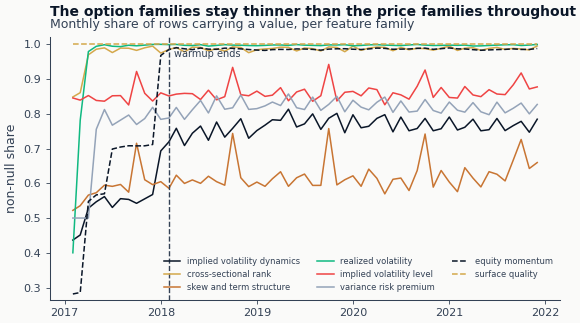

In [17]:
plot_coverage_through_time(
    coverage,
    warmup_boundary=WARMUP_END,
    title="The option families stay thinner than the price families throughout",
    subtitle="Monthly share of rows carrying a value, per feature family",
    alt=(
        "Line chart of the share of rows carrying a value, by feature family, by month, on an "
        "axis running from about 0.27 to one. Equity momentum starts lowest at roughly 0.28 and "
        "climbs through 2017, stepping up to one at the marked warmup boundary at the start of "
        "2018. Realized volatility climbs from about 0.4 to one within the first two months and "
        "stays flat there. Surface quality and the cross-sectional ranks run just under one for "
        "the rest of the sample and the implied volatility level a little below them, between "
        "about 0.84 and 0.93. The implied volatility dynamics and the variance risk premium sit "
        "lower again, between roughly 0.68 and 0.82, and skew and term structure is lowest and "
        "the most ragged throughout, swinging between about 0.55 and 0.75. Every option-derived "
        "family is ragged month to month where the two price families are smooth."
    ),
)

### F4. The timing contract

The bars are the register's declaration, one per family, and a family's declaration is a single
bound rather than a per-column statement. For six of the eight it is the longest reach of any
member. For the cross-sectional ranks it is not: that family is declared at a year with a
one-session delay, while the longest-reaching of the eight columns it ranks is the 63-session
return and three of them are share-price columns carrying no delay at all. The declaration
overstates on both counts, so the bar is wider and later than the family reads and nothing
leaks. The audit in D.2 is stated per column for that reason, though it covers the emitted
levels rather than the percentiles taken from them; a percentile inherits whatever warmup its
source had, because a null source takes a null rank.

The delay is the other half of the contract and it is the half this figure cannot resolve: one
session against a lookback of up to a year is thinner than the line that draws the bar, so six
of the eight bars appear to touch the decision line when only two of them do. The register
printed in Section A is where the delay is legible.

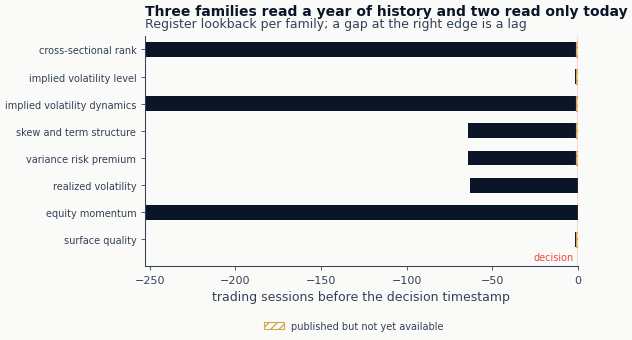

In [18]:
plot_timing_contract(
    FAMILIES,
    bar_unit="trading sessions",
    title="Three families read a year of history and two read only today",
    subtitle="Register lookback per family; a gap at the right edge is a lag",
    alt=(
        "Horizontal bars, one per feature family, each extending leftward from the decision "
        "line at zero by that family's lookback. The cross-sectional ranks, the implied "
        "volatility dynamics and equity momentum run the full width of the axis to minus 252 "
        "sessions. Skew and term structure, the variance risk premium and realized volatility "
        "reach about minus 63. The implied volatility level and the surface quality family have "
        "a lookback of one session and are drawn as a sliver at the right edge, the second of "
        "them behind the legend. The one-session delay the register carries for the six "
        "option-derived families is too narrow to be visible at this scale."
    ),
)

## F. What the features look like

Four properties decide whether this matrix can be used at all: the scale each feature arrives
on, whether the cross-section disagrees enough to rank on, how much of the set is one ordering
under several names, and how long a value lasts. Whether any of it predicts is
`05_evaluation`'s question, and it is asked there fold by fold rather than here on the whole
sample.

### F2. Feature distributions

The implied volatility family is shown on the scales a reader would judge it: the level, its
session-over-session change, its two z-scores, where it stands in its own trailing range, and
its standing among the names quoted that session. The same quantity looks completely different
in level, in z-score and in percentile form, which is the point of carrying all three.

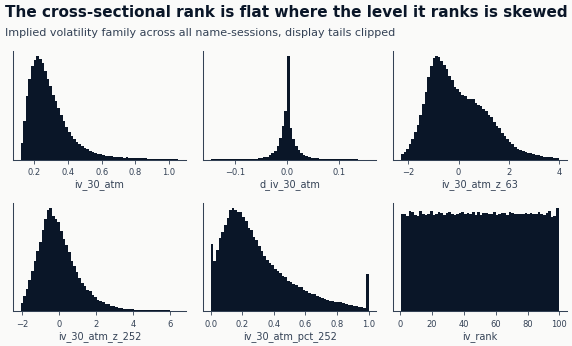

In [19]:
plot_feature_distributions(
    features,
    [
        "iv_30_atm",
        "d_iv_30_atm",
        f"iv_30_atm_z_{W['iv_zscore'][0]}",
        f"iv_30_atm_z_{W['iv_zscore'][1]}",
        f"iv_30_atm_pct_{W['iv_percentile']}",
        "iv_rank",
    ],
    title="The cross-sectional rank is flat where the level it ranks is skewed",
    subtitle="Implied volatility family across all name-sessions, display tails clipped",
    alt=(
        "Six histograms in two rows. The level is a right-skewed hump peaking near 0.22 with a "
        "long upper tail reaching one. Its session-over-session change is a narrow spike at "
        "zero. The two z-scores are broad and themselves right-skewed, the 63-session one "
        "spanning about minus two to four and the 252-session one reaching six. The position "
        "within the trailing range is right-skewed across its zero-to-one span with a spike at "
        "each end, and the percentile among the names quoted that session is close to uniform "
        "across zero to a hundred."
    ),
)

### F3. Cross-sectional dispersion through time

A cross-sectional strategy needs the cross-section to disagree. On a date where the band
narrows to nothing there is nothing to rank, whatever the average level of implied volatility.
The band drawn here is taken across the names quoted within each single session, and only the
monthly summary of those daily bands is plotted, so what it measures is how far the names stood
apart on a session - which is the only spread a ranking model is scored on. The column shown is
the variance risk premium, because that is the quantity the hypothesis ranks on.

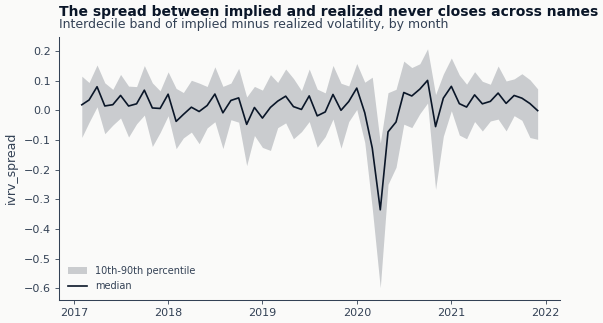

In [20]:
plot_cross_sectional_dispersion(
    features,
    "ivrv_spread",
    every="1mo",
    title="The spread between implied and realized never closes across names",
    subtitle="Interdecile band of implied minus realized volatility, by month",
    alt=(
        "Shaded band of the 10th to 90th percentile of implied minus realized volatility by "
        "month, with the median drawn through it. The median sits a little above zero for most "
        "of the sample and the band runs roughly minus 0.05 to plus 0.1. In the first quarter of "
        "2020 the median drops to about minus 0.32 and the lower edge of the band to about minus "
        "0.6 as realized volatility overtakes implied. Through the rest of 2020 the median "
        "recovers above zero and the band stays wider than before, narrowing again during 2021. "
        "The band is never a single line."
    ),
)

### F5. Redundancy structure

Clustering on the distance $1 - |\rho|$ groups features that carry the same ordering, whatever
the sign. Above the cut two features are close enough that a linear model cannot separate their
contributions. This states the clusters and stops there. `05_evaluation` reports the pairs above
the same cut beside its own fold-aware screen, and **nothing downstream then drops one member of
a pair**: the model notebooks read the whole matrix and the correlated columns reach the
estimators together. What the clustering is for is the reader's judgement of a fitted model - a
linear coefficient split across four columns carrying one ordering says less about that ordering
than its size suggests, and a tree-based importance divides the same way.

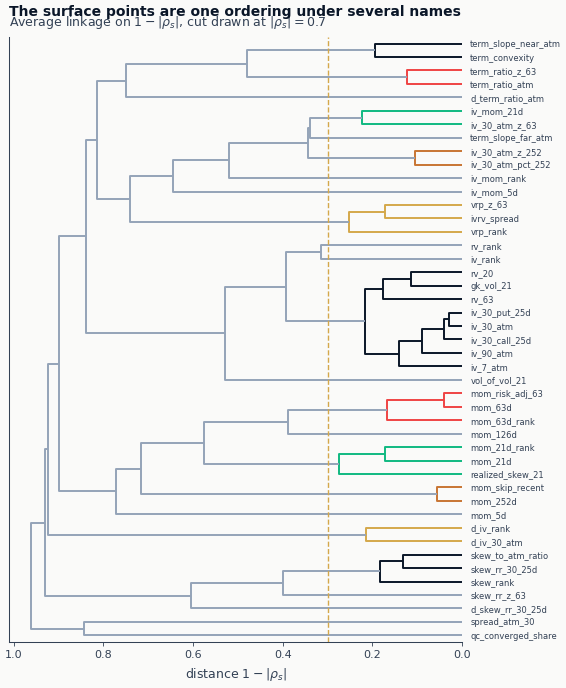

In [21]:
CUT = 0.7
clusters = plot_redundancy_clusters(
    features,
    feature_cols,
    cut=CUT,
    title="The surface points are one ordering under several names",
    subtitle=r"Average linkage on $1 - |\rho_s|$, cut drawn at $|\rho_s| = 0.7$",
    alt=(
        "Dendrogram of every feature in the matrix, distance running from one on the left to "
        "zero on the right with the cut drawn as a dashed vertical line. The tightest cluster is "
        "the three at-the-money implied volatility maturities with the two 25-delta wings, which "
        "join at almost zero distance. The two realized volatility windows and the Garman-Klass "
        "estimator form a second tight cluster, and the implied volatility and realized "
        "volatility ranks attach to that combined block. The variance risk premium, its z-score "
        "and its rank form a third. The 252-session z-score joins the position within the "
        "trailing range, and each momentum horizon sits with its own percentile. The term "
        "structure columns form their own block apart from the far slope, which sits among the "
        "implied volatility dynamics instead, and the skew columns form another block. The two "
        "surface quality columns branch off at the root, sharing an ordering with nothing else."
    ),
)

### F6. Persistence and rank stability

The right-hand panel compares the ordering across consecutive **rebalances**, which
`config/setup.yaml` declares as a Friday close. The autocorrelation on the left is of the
feature, not of the return, and it runs to four decision cycles. A feature whose value has
decayed before the next rebalance cannot support that cadence, however well it predicts on the
day it is computed. It is estimated per security on pairs of dates exactly one lag apart and
summarized by the median over securities, with a bootstrap interval over them, so that it
measures whether a name holds its own value rather than whether names sit at different levels.

The entity here is the security rather than the ticker, for the reason Section B gave, which is
why the figure is drawn from the panel before `sec_id` was dropped rather than from the emitted
matrix. A ticker reassigned to a new company would otherwise let this measurement read one
company's value against another's and report the result as persistence.

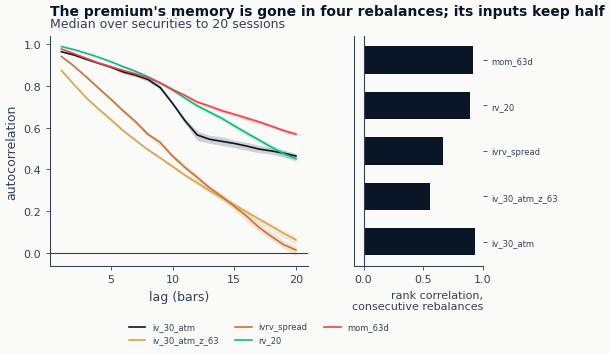

In [22]:
DECISION_DATES = (
    features.group_by(pl.col("timestamp").dt.truncate("1w"))
    .agg(pl.col("timestamp").max().alias("decision"))["decision"]
    .sort()
    .to_list()
)

plot_persistence(
    built,
    [
        "iv_30_atm",
        f"iv_30_atm_z_{W['iv_zscore'][0]}",
        "ivrv_spread",
        f"rv_{W['realized_vol'][0]}",
        f"mom_{W['momentum'][2]}d",
    ],
    entity=SECURITY,
    max_lag=4 * DECISION_CYCLE,
    decision_dates=DECISION_DATES,
    title="The premium's memory is gone in four rebalances; its inputs keep half",
    subtitle=f"Median over securities to {4 * DECISION_CYCLE} sessions",
    alt=(
        "Two panels. On the left, autocorrelation against lag in sessions: all five series start "
        "near one. The quarterly return decays slowest and is still near 0.57 at twenty "
        "sessions; the realized volatility and the implied volatility level are both near 0.46 "
        "there. The implied volatility z-score and the implied-minus-realized spread fall much "
        "faster and are close to zero by twenty sessions, the spread the lower of the two at the "
        "end. The bootstrap ribbon is narrow enough to be hard to see except around the implied "
        "volatility level. On the right, the cross-sectional rank correlation between "
        "consecutive weekly rebalances: the implied volatility level and the quarterly return "
        "are highest at about 0.9, the realized volatility just below them, the "
        "implied-minus-realized spread about 0.65 and the z-score lowest at about 0.55."
    ),
)

Cutting the redundancy tree at $|\rho_s| = 0.7$ leaves **24 clusters** across the **45**
columns, so nearly half the matrix repeats an ordering another column already carries.

In [23]:
print(f"{len(set(clusters.values()))} clusters over {len(feature_cols)} features at cut {CUT}")

24 clusters over 45 features at cut 0.7


## G. Emit

The matrix goes to `features/financial.parquet`, and it is read twice.
[`04_model_based_features`](04_model_based_features.ipynb) reads the implied volatility level
out of it and subtracts a conditional volatility it estimates from prices, which gives a second
version of the premium built here; it reads this notebook's premium column too, to compare the
two. [`05_evaluation`](05_evaluation.ipynb) reads the whole matrix and tests fold by fold
whether any of it predicts.

Beside the parquet goes a small JSON file called a **digest sidecar**. It records a hash of the
values in the matrix, its row count, its key columns, and a hash of each panel the matrix was
built from. The hash is taken over the content rather than over the file's bytes, so writing the
same values again in a different row order leaves it alone and changing any one value moves it.
That is what makes it useful to a later stage: a stage that recorded which matrix it trained on
can tell whether the matrix has since changed, which a file name and a modification time cannot.
This stage reads no upstream case-study artifact, so the panels it records are the two loaded
ones, each restricted to the columns and window actually consumed.

In [24]:
record = write_artifact(
    features,
    FEATURES_DIR / "financial.parquet",
    keys=PANEL_KEY,
    written_by=f"case_studies/{CASE_STUDY_ID}/03_financial_features.py",
    inputs={
        "load_sp500_daily_bars": value_digest(
            daily.select([*PANEL_KEY, SECURITY, "open", "high", "low", "close", "adj_factor"])
        ),
        "load_sp500_options_surface": value_digest(surface_raw.select([*PANEL_KEY, *SURFACE_COLS])),
    },
)
print(f"Wrote {display_path(FEATURES_DIR / 'financial.parquet')}, digest {record['digest']}")
print(f"Read by 04_model_based_features.py and 05_evaluation.py, on {PANEL_KEY}")

Wrote case_studies/sp500_equity_option_analytics/features/financial.parquet, digest f04e716c76ece810
Read by 04_model_based_features.py and 05_evaluation.py, on ['symbol', 'timestamp']


## Key takeaways

- **State the timing contract before writing the feature.** The register fixes each family's
  lookback and lag in the configuration, and the warmup assertion, the timing figure and the
  review a reader can run all read those numbers rather than re-deriving them from the code.
- **Put a sparse input on a dense calendar before you shift it.** A shift over a panel's own
  rows moves back one *row*, which is one trading session only where the panel has a row on
  every session. Reindexing the surface onto the security's own sessions first is what makes the
  one-session lag, the carry-forward limit and every window after them mean sessions.
- **Rank inside the frame a decision is taken over.** A percentile within the decision date is
  the ordering a long-short book acts on; a rank pooled across dates answers a different
  question with the same arithmetic.
- **Test the seal by construction, not by inspection.** Rebuilding the matrix from inputs that
  stop at the boundary and comparing values catches any transform that fits across the sample,
  including the ones nobody thought to flag.
- **Read the matrix before modelling it.** Distribution, dispersion, redundancy and decay each
  rule out a use: a feature with no cross-sectional spread cannot rank, and one whose ordering
  decays inside the rebalance cycle cannot be traded at that cadence.

### Known limitations

- The carry forward makes a value stale rather than missing. It reaches backward only, so it
  cannot leak, but a carried level is indistinguishable from one that was quoted and did not
  move, and nothing emitted here records how old a value is. The two surface quality columns do
  not fill that gap: they describe the last solve, not its age.
- A failed volatility solve leaves a gap the carry forward only partly closes, so the
  option-derived columns never reach the coverage of the price columns and the measures taken
  between two maturities reach it least. A model trained on this matrix therefore sees a
  different number of rows per feature, and how it handles a missing value is a modelling choice
  rather than something settled here.
- Garman-Klass is taken entirely within the session, so it cannot see the overnight move at all;
  close-to-close spans that move but reads one price per session and needs a long window to
  settle. Carrying both is what covers the two, and neither one on its own does.
- The cross-sectional percentiles are taken over every name quoted on a date rather than over a
  liquidity-screened subset, so a thinly quoted name occupies a rank position it may not be
  tradable at. `setup.yaml` declares that screen and a later stage applies it.

**Next**: `04_model_based_features.py` adds the features that are themselves model outputs,
where the rule is estimated from the data rather than written in advance.